In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from crackmnist.dataset import CrackMNIST

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.9.1+cu130
CUDA: True
GPU: NVIDIA GeForce RTX 5070


In [30]:
# ==========================================
# 2. CONFIGURACIÓN GLOBAL
# ==========================================
PIXELS = 64       # 28, 64 o 128
SIZE = "S"

BATCH_SIZE = 64
EPOCHS = 20

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"\n--> Ejecutando pipeline para resolución: "
      f"{PIXELS}x{PIXELS} en {DEVICE}")


PyTorch: 2.9.1+cu130
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5070

--> Ejecutando pipeline para resolución: 64x64 en cuda


In [32]:
# ==========================================
# 3. CARGA DE DATASETS
# ==========================================

train_base = CrackMNIST(
    split="train",
    pixels=64,
    size="S",
    task="crack_tip_segmentation"
)

val_base = CrackMNIST(
    split="val",
    pixels=PIXELS,
    size=SIZE,
    task="crack_tip_segmentation"
)

test_base = CrackMNIST(
    split="test",
    pixels=PIXELS,
    size=SIZE,
    task="crack_tip_segmentation"
)

print("\nDatasets cargados:")
print(f"Train: {len(train_base)}")
print(f"Validation: {len(val_base)}")
print(f"Test: {len(test_base)}")


100.0%



Datasets cargados:
Train: 10048
Validation: 5944
Test: 5944


In [33]:
# ==========================================
# 4. WRAPPER PARA PYTORCH
# ==========================================

class CrackTipDataset(Dataset):

    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        image, mask = self.base_dataset[idx]

        # Convertir a numpy si viene como Tensor
        if torch.is_tensor(image):
            image = image.numpy()

        if torch.is_tensor(mask):
            mask = mask.numpy()

        # Imagen:
        # [2, H, W]
        image_tensor = torch.tensor(
            image,
            dtype=torch.float32
        )

        # Máscara:
        # [H, W] → [1, H, W]
        mask_tensor = torch.tensor(
            (mask > 0).astype(np.float32),
            dtype=torch.float32
        ).unsqueeze(0)

        return image_tensor, mask_tensor


train_torch = CrackTipDataset(train_base)
val_torch = CrackTipDataset(val_base)
test_torch = CrackTipDataset(test_base)


In [34]:
# ==========================================
# 5. DATALOADERS
# ==========================================

train_loader = DataLoader(
    train_torch,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_torch,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_torch,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [35]:
# ==========================================
# 6. VERIFICAR DIMENSIONES
# ==========================================

sample_img, sample_mask = next(iter(train_loader))

print("\nDimensiones:")
print(f"Batch de imágenes: {sample_img.shape}")
print(f"Batch de máscaras: {sample_mask.shape}")

# Esperado:
# imágenes  -> [64, 2, 28, 28]
# máscaras  -> [64, 1, 28, 28]



Dimensiones:
Batch de imágenes: torch.Size([64, 2, 64, 64])
Batch de máscaras: torch.Size([64, 1, 64, 64])


In [36]:
# ==========================================
# 7. ARQUITECTURA DEL MODELO
# ==========================================

class FlexibleCrackTipCNN(nn.Module):

    def __init__(self, in_channels=2):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Salida:
            # 1 logit por píxel
            nn.Conv2d(
                32,
                1,
                kernel_size=1
            )
        )

    def forward(self, x):
        return self.net(x)


# Crear modelo
model = FlexibleCrackTipCNN().to(DEVICE)

print("\nModelo:")
print(model)



Modelo:
FlexibleCrackTipCNN(
  (net): Sequential(
    (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [37]:
# ==========================================
# 8. FUNCIÓN DE PÉRDIDA
# ==========================================

# Hay solamente 1 píxel positivo
# frente a PIXELS² - 1 negativos.

pos_weight_value = float(
    PIXELS * PIXELS - 1
)

pos_weight = torch.tensor(
    [pos_weight_value],
    device=DEVICE
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(f"\npos_weight = {pos_weight_value}")




pos_weight = 4095.0


In [38]:
# ==========================================
# 9. MÉTRICA:
#    DISTANCIA AL CRACK TIP
# ==========================================

def crack_tip_distance(
    logits,
    masks,
    pixels
):

    batch_size = logits.shape[0]

    distances = []

    for i in range(batch_size):

        # ----------------------------------
        # Predicción
        # ----------------------------------

        pred_flat = torch.argmax(
            logits[i].view(-1)
        )

        pred_y = pred_flat // pixels
        pred_x = pred_flat % pixels

        # ----------------------------------
        # Posición real
        # ----------------------------------

        target_positions = torch.nonzero(
            masks[i, 0] > 0
        )

        if len(target_positions) == 0:
            continue

        true_y = target_positions[0, 0]
        true_x = target_positions[0, 1]

        # ----------------------------------
        # Distancia euclidiana
        # ----------------------------------

        dist = torch.sqrt(
            (pred_x.float() - true_x.float()) ** 2
            +
            (pred_y.float() - true_y.float()) ** 2
        )

        distances.append(dist.item())

    if len(distances) > 0:
        return np.mean(distances)

    return np.nan


In [39]:
# ==========================================
# 10. ENTRENAMIENTO
# ==========================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        # Forward
        logits = model(images)

        # Loss
        loss = criterion(
            logits,
            masks
        )

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [40]:
# ==========================================
# 11. EVALUACIÓN
# ==========================================

def evaluate(
    model,
    loader,
    criterion,
    device,
    pixels
):

    model.eval()

    total_loss = 0.0
    distances = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            # Forward
            logits = model(images)

            # Loss
            loss = criterion(
                logits,
                masks
            )

            total_loss += loss.item()

            # Distancia
            dist = crack_tip_distance(
                logits.cpu(),
                masks.cpu(),
                pixels
            )

            if not np.isnan(dist):
                distances.append(dist)

    mean_loss = total_loss / len(loader)

    if len(distances) > 0:
        mean_distance = np.mean(distances)
    else:
        mean_distance = np.nan

    return mean_loss, mean_distance

In [41]:
# ==========================================
# 12. ENTRENAMIENTO COMPLETO
# ==========================================

print("\n" + "=" * 60)
print("INICIO DEL ENTRENAMIENTO")
print("=" * 60)

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_dist = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
        PIXELS
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dist: {val_dist:.2f} px"
    )



INICIO DEL ENTRENAMIENTO
Epoch 01/20 | Train Loss: 0.8209 | Val Loss: 0.9200 | Val Dist: 7.68 px
Epoch 02/20 | Train Loss: 0.2632 | Val Loss: 1.2164 | Val Dist: 3.85 px
Epoch 03/20 | Train Loss: 0.1426 | Val Loss: 3.9820 | Val Dist: 4.78 px
Epoch 04/20 | Train Loss: 0.0989 | Val Loss: 4.7184 | Val Dist: 15.65 px
Epoch 05/20 | Train Loss: 0.1008 | Val Loss: 10.9971 | Val Dist: 14.48 px


KeyboardInterrupt: 

In [ ]:
# ==========================================
# 13. VISUALIZACIÓN DE PREDICCIÓN
# ==========================================

def plot_prediction(
    idx,
    dataset,
    model,
    device,
    pixels
):

    image, mask = dataset[idx]

    model.eval()

    with torch.no_grad():

        logits = model(
            image.unsqueeze(0).to(device)
        )

    # ----------------------------------
    # Predicción
    # ----------------------------------

    pred_flat = torch.argmax(
        logits.view(-1)
    )

    pred_y = (
        pred_flat // pixels
    ).item()

    pred_x = (
        pred_flat % pixels
    ).item()

    # ----------------------------------
    # Posición real
    # ----------------------------------

    true_pos = torch.nonzero(
        mask[0] > 0
    )

    if len(true_pos) > 0:

        true_x = true_pos[0, 1].item()
        true_y = true_pos[0, 0].item()

    else:

        true_x = None
        true_y = None

    # ----------------------------------
    # Campos de desplazamiento
    # ----------------------------------

    ux = image[0].numpy()
    uy = image[1].numpy()

    # ----------------------------------
    # Plot
    # ----------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5)
    )

    for ax, field, title in zip(
        axes,
        [ux, uy],
        [r"$u_x$", r"$u_y$"]
    ):

        im = ax.imshow(
            field,
            origin="upper"
        )

        # Predicción
        ax.scatter(
            pred_x,
            pred_y,
            s=120,
            marker="x",
            c="red",
            linewidths=2,
            label="Predicción"
        )

        # Ground truth
        if true_x is not None:

            ax.scatter(
                true_x,
                true_y,
                s=120,
                facecolors="none",
                edgecolors="lime",
                linewidths=2,
                label="Real"
            )

        ax.set_title(
            f"{title} ({pixels}x{pixels})"
        )

        ax.set_xlim(
            -0.5,
            pixels - 0.5
        )

        ax.set_ylim(
            pixels - 0.5,
            -0.5
        )

        ax.legend()

        plt.colorbar(
            im,
            ax=ax
        )

    plt.tight_layout()

    plt.show()


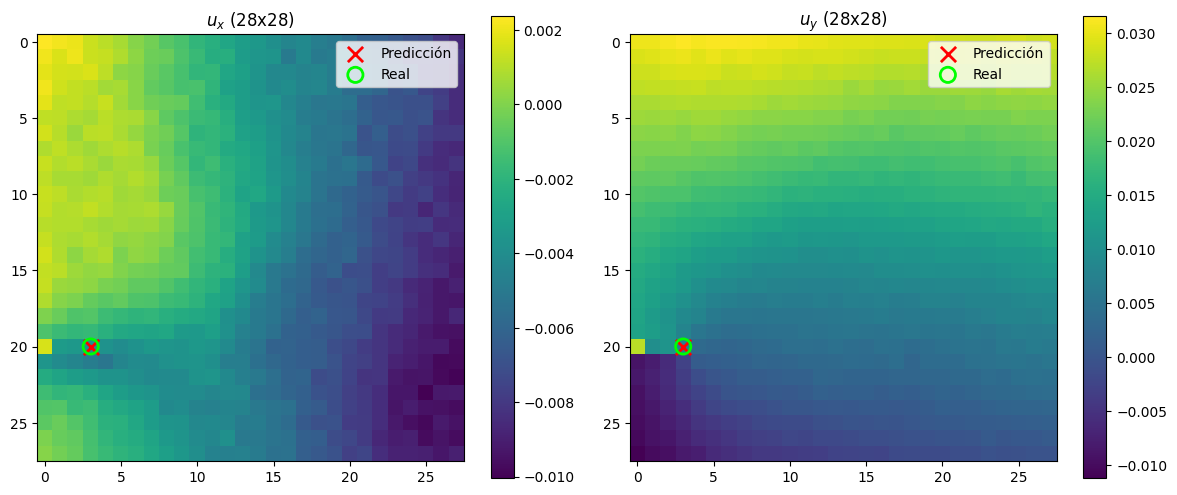

In [ ]:
# ==========================================
# 14. PROBAR UNA MUESTRA DE VALIDACIÓN
# ==========================================

plot_prediction(
    300,
    val_torch,
    model,
    DEVICE,
    PIXELS
)

Usando dispositivo: cuda
Cargando dataset CrackMNIST con tamaño 64x64...

Iniciando entrenamiento...
Epoch 01/10 | Train Loss: 3.5894 | Val Loss: 2.1386 | Val Distance: 19.40 px
Epoch 02/10 | Train Loss: 1.2873 | Val Loss: 1.0356 | Val Distance: 20.85 px
Epoch 03/10 | Train Loss: 1.0634 | Val Loss: 0.9904 | Val Distance: 19.28 px
Epoch 04/10 | Train Loss: 1.0412 | Val Loss: 1.0115 | Val Distance: 18.36 px
Epoch 05/10 | Train Loss: 1.0133 | Val Loss: 1.0525 | Val Distance: 17.20 px
Epoch 06/10 | Train Loss: 0.9976 | Val Loss: 1.0519 | Val Distance: 15.54 px
Epoch 07/10 | Train Loss: 0.9987 | Val Loss: 1.1184 | Val Distance: 14.82 px
Epoch 08/10 | Train Loss: 0.9617 | Val Loss: 1.0783 | Val Distance: 11.90 px
Epoch 09/10 | Train Loss: 0.9428 | Val Loss: 1.1455 | Val Distance: 9.22 px
Epoch 10/10 | Train Loss: 0.9304 | Val Loss: 1.1333 | Val Distance: 8.90 px

Evaluación de distancias en conjunto de validación...
Error medio: 8.95 px
Mediana: 2.24 px
Error máximo: 65.80 px
Error ≤ 1px: 24

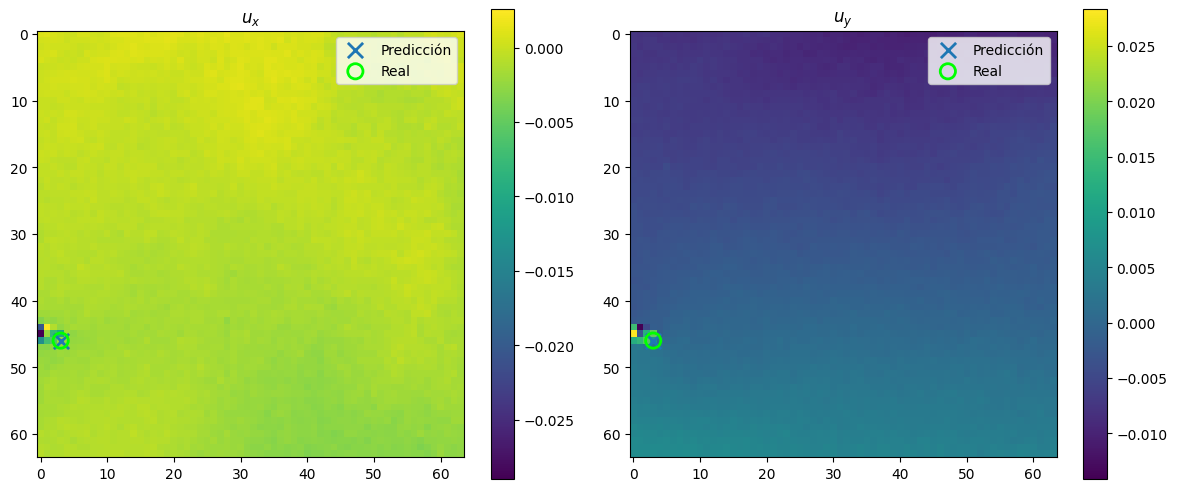

Real: (3, 46) | Predicción: (3, 46)


In [42]:
# ==========================================
# 1. Dataset Wrapper (Independiente del tamaño)
# ==========================================
class CrackTipDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, mask = self.base_dataset[idx]

        # Convertir a Tensor de PyTorch si viene como ndarray
        if not torch.is_tensor(image):
            image = torch.tensor(image, dtype=torch.float32)
        else:
            image = image.to(torch.float32)

        if not isinstance(mask, np.ndarray):
            mask = np.array(mask)

        # Máscara: 0/255 -> 0/1 con canal de dimensión (1, H, W)
        mask_binary = (mask > 0).astype(np.float32)
        mask_tensor = torch.tensor(mask_binary, dtype=torch.float32).unsqueeze(0)

        return image, mask_tensor

# ==========================================
# 2. Modelo FCN (Totalmente Fully Convolutional)
# ==========================================
class CrackTipCNN(nn.Module):
    """
    Red convolucional totalmente fully-convolutional.
    Al no usar capas Fully Connected (Linear), se adapta automáticamente
    a cualquier tamaño espacial (28x28, 64x64, 128x128, etc.).
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=1, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 3. Métricas y Evaluación adaptables a H, W
# ==========================================
def crack_tip_distance(logits, masks):
    """
    Calcula la distancia en píxeles ajustándose dinámicamente
     al ancho (W) y alto (H) de las imágenes.
    """
    batch_size, _, height, width = logits.shape
    distances = []

    for i in range(batch_size):
        pred_flat = torch.argmax(logits[i].view(-1))
        pred_y = (pred_flat // width).item()
        pred_x = (pred_flat % width).item()

        target_positions = torch.nonzero(masks[i, 0] > 0)
        if len(target_positions) == 0:
            continue

        true_y = target_positions[0, 0].item()
        true_x = target_positions[0, 1].item()

        distance = np.sqrt((pred_x - true_x)**2 + (pred_y - true_y)**2)
        distances.append(distance)

    if len(distances) == 0:
        return np.nan
    return np.mean(distances)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    distances = []

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)
            total_loss += loss.item()

            distance = crack_tip_distance(logits.cpu(), masks.cpu())
            if not np.isnan(distance):
                distances.append(distance)

    mean_loss = total_loss / len(loader)
    mean_distance = np.mean(distances) if len(distances) > 0 else np.nan
    return mean_loss, mean_distance

def get_prediction_distances(model, loader, device):
    model.eval()
    distances = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            logits = model(images)

            _, _, H, W = logits.shape

            pred_indices = torch.argmax(logits.view(logits.shape[0], -1), dim=1)
            pred_y = pred_indices // W
            pred_x = pred_indices % W

            for i in range(len(pred_x)):
                target_positions = torch.nonzero(masks[i, 0] > 0)
                if len(target_positions) == 0:
                    continue

                true_y = target_positions[0, 0]
                true_x = target_positions[0, 1]

                distance = torch.sqrt(
                    (pred_x[i].float() - true_x.float())**2 +
                    (pred_y[i].float() - true_y.float())**2
                )
                distances.append(distance.item())

    return np.array(distances)

def plot_prediction(idx, dataset, model, device):
    image, mask = dataset[idx]
    model.eval()

    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))

    _, _, H, W = logits.shape
    pred_flat = torch.argmax(logits.view(-1))
    pred_y = (pred_flat // W).item()
    pred_x = (pred_flat % W).item()

    true_pos = torch.nonzero(mask[0] > 0)
    if len(true_pos) > 0:
        true_y = true_pos[0, 0].item()
        true_x = true_pos[0, 1].item()
    else:
        true_x, true_y = None, None

    ux = image[0].numpy()
    uy = image[1].numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, field, title in zip(axes, [ux, uy], [r"$u_x$", r"$u_y$"]):
        im = ax.imshow(field, origin="upper")
        ax.scatter(pred_x, pred_y, s=120, marker="x", linewidths=2, label="Predicción")

        if true_x is not None:
            ax.scatter(true_x, true_y, s=120, facecolors="none", edgecolors="lime", linewidths=2, label="Real")

        ax.set_title(title)
        ax.legend()
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

    print(f"Real: ({true_x}, {true_y}) | Predicción: ({pred_x}, {pred_y})")

# ==========================================
# 4. Pipeline Principal
# ==========================================
def main():
    # --- Configuración ---
    PIXELS = 64  # Podés cambiar a 28, 64 o 128
    BATCH_SIZE = 64
    EPOCHS = 10
    LR = 1e-3

    # El peso positivo escala dinámicamente según el número de píxeles (H * W - 1)
    POS_WEIGHT = float(PIXELS * PIXELS - 1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Usando dispositivo: {device}")
    print(f"Cargando dataset CrackMNIST con tamaño {PIXELS}x{PIXELS}...")

    # --- Inicialización del Dataset ---
    train_dataset = CrackMNIST(split="train", pixels=PIXELS, size="S", task="crack_tip_segmentation")
    val_dataset   = CrackMNIST(split="val",   pixels=PIXELS, size="S", task="crack_tip_segmentation")
    test_dataset  = CrackMNIST(split="test",  pixels=PIXELS, size="S", task="crack_tip_segmentation")

    train_torch = CrackTipDataset(train_dataset)
    val_torch   = CrackTipDataset(val_dataset)
    test_torch  = CrackTipDataset(test_dataset)

    train_loader = DataLoader(train_torch, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_torch, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_torch, batch_size=BATCH_SIZE, shuffle=False)

    # --- Modelo y Entrenamiento ---
    model = CrackTipCNN().to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    print("\nIniciando entrenamiento...")
    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_distance = evaluate(model, val_loader, criterion, device)

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Distance: {val_distance:.2f} px"
        )

    # --- Evaluación Final ---
    print("\nEvaluación de distancias en conjunto de validación...")
    val_distances = get_prediction_distances(model, val_loader, device)

    print(f"Error medio: {val_distances.mean():.2f} px")
    print(f"Mediana: {np.median(val_distances):.2f} px")
    print(f"Error máximo: {val_distances.max():.2f} px")
    print(f"Error ≤ 1px: {np.mean(val_distances <= 1) * 100:.2f}%")
    print(f"Error ≤ 2px: {np.mean(val_distances <= 2) * 100:.2f}%")

    # Graficar una muestra aleatoria
    plot_prediction(0, val_torch, model, device)

if __name__ == "__main__":
    main()

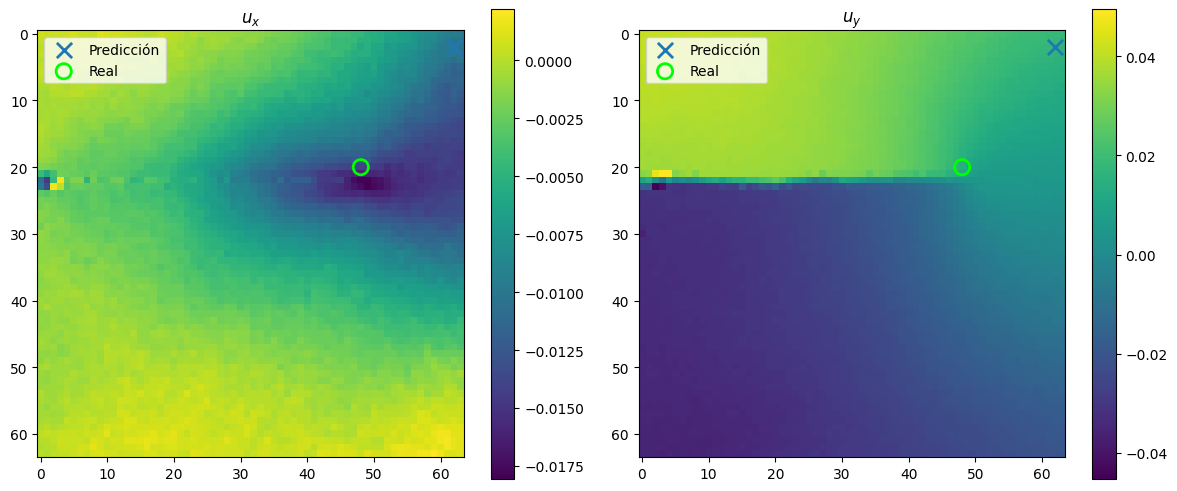

Real: (48, 20) | Predicción: (62, 2)


In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plot_prediction(4000, val_torch, model, device)